<a href="https://colab.research.google.com/github/fabriciosgouveia/Angular_agendacontados/blob/main/FabricioSebastiaoDeGouveia_Processameto_Linguagem_Natural_PNL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# PIPELINE PROJETO B2W
# Corpus: Avaliações de e-commerce
# ============================================================

# --- 0. INSTALAÇÕES E IMPORTS ---

!pip install spacy gensim wordcloud pyvis scikit-learn umap-learn
!python -m spacy download pt_core_news_lg

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# PLN
import spacy
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer
from nltk.stem.snowball import SnowballStemmer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('rslp')
nltk.download('punkt_tab')

nlp = spacy.load('pt_core_news_lg')

# Representações
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import Word2Vec

# Modelagem e Classificação
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score)
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.preprocessing import LabelEncoder

# Visualisações
from wordcloud import WordCloud
import umap

# Grafo
import networkx as nx
from pyvis.network import Network

print("Ambiente configurado")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 113.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.2/568.2 MB 1.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Unzipping stemmers/rslp.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Ambiente configurado


In [5]:
# ============================================================
# SEÇÃO 1: CARREGAMENTO E EDA TEXTUAL
# ============================================================

# --- 1.1 Carregamento ---
# Dataset: https://www.kaggle.com/datasets/fredericods/ptbr-sentiment-analysis-datasets
# Arquivo: b2w.csv

df = pd.read_csv('b2w.csv', on_bad_lines='warn')
print("Columns in the loaded DataFrame:", df.columns.tolist())

# Selecionamos as colunas mas relevantes e removemos nulos
colunas = ['review_text', 'rating']
df = df[colunas].dropna(subset=['review_text', 'rating']).copy()

# Criar rótulo de sentimento baseado na nota
# 1-2: negativo | 3: neutro | 4-5: positivo
def rotular_sentimento(nota):
    if nota <= 2:
        return 'negativo'
    elif nota == 3:
        return 'neutro'
    else:
        return 'positivo'

df['sentimento'] = df['rating'].apply(rotular_sentimento)

print(f"Corpus carregado: {len(df):,} avaliações")
print(f"Colunas: {df.columns.tolist()}")
df.head(3)

Columns in the loaded DataFrame: ['original_index', 'review_text', 'review_text_processed', 'review_text_tokenized', 'polarity', 'rating', 'kfold_polarity', 'kfold_rating']
Corpus carregado: 136,500 avaliações
Colunas: ['review_text', 'rating', 'sentimento']


,review_text,rating,sentimento
0,Bem macio e felpudo...recomendo. Preço imbatí...,4,positivo
1,Produto excepcional! recomendo!!! inovador e ...,5,positivo
2,recebi o produto antes do prazo mas veio com d...,1,negativo


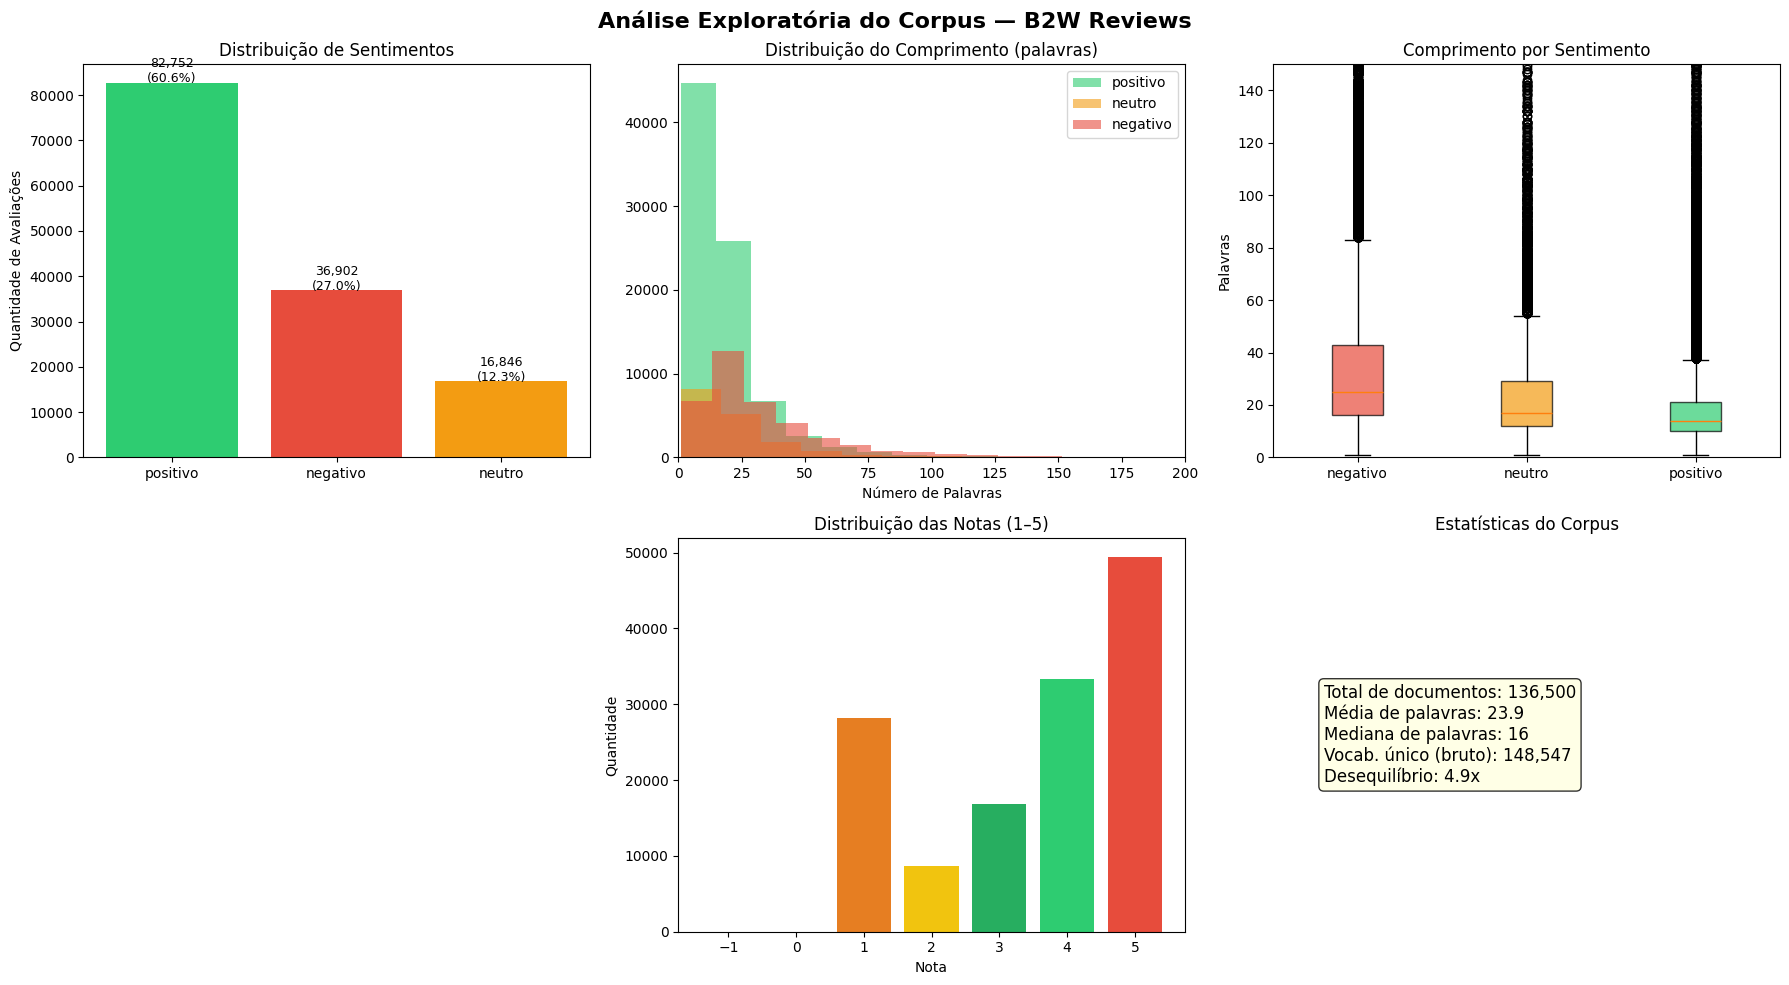


 Iterpretação EDA:
O corpus apresenta forte desequilíbrio de classes: avaliações positivas dominam
com 61% do total. Textos negativos tendem
a ser mais longos (mediana maior), sugerindo que clientes insatisfeitos elaboram
mais suas reclamações — padrão relevante para o modelo de classificação.


In [6]:
# --- 1.2 EDA Textual ---

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Análise Exploratória do Corpus — B2W Reviews', fontsize=16, fontweight='bold')

# Distribuição de sentimentos
contagem = df['sentimento'].value_counts()
cores = {'positivo': '#2ecc71', 'neutro': '#f39c12', 'negativo': '#e74c3c'}
axes[0, 0].bar(contagem.index, contagem.values,
               color=[cores[s] for s in contagem.index])
axes[0, 0].set_title('Distribuição de Sentimentos')
axes[0, 0].set_ylabel('Quantidade de Avaliações')
for i, (idx, val) in enumerate(contagem.items()):
    axes[0, 0].text(i, val + 100, f'{val:,}\n({val/len(df)*100:.1f}%)',
                    ha='center', fontsize=9)

# Comprimento dos textos por sentimento
df['num_chars'] = df['review_text'].str.len()
df['num_words'] = df['review_text'].str.split().str.len()

for sent, cor in cores.items():
    subset = df[df['sentimento'] == sent]['num_words']
    axes[0, 1].hist(subset, bins=50, alpha=0.6, label=sent, color=cor)
axes[0, 1].set_title('Distribuição do Comprimento (palavras)')
axes[0, 1].set_xlabel('Número de Palavras')
axes[0, 1].set_xlim(0, 200)
axes[0, 1].legend()

# Boxplot de comprimento por sentimento
df_box = df[['sentimento', 'num_words']]
sentimentos_order = ['negativo', 'neutro', 'positivo']
data_box = [df[df['sentimento'] == s]['num_words'].values for s in sentimentos_order]
bp = axes[0, 2].boxplot(data_box, labels=sentimentos_order, patch_artist=True)
for patch, sent in zip(bp['boxes'], sentimentos_order):
    patch.set_facecolor(cores[sent])
    patch.set_alpha(0.7)
axes[0, 2].set_title('Comprimento por Sentimento')
axes[0, 2].set_ylabel('Palavras')
axes[0, 2].set_ylim(0, 150)

# Top categorias (removed as 'site_category_lv1' is no longer available)
axes[1, 0].axis('off') # Turn off the unused subplot

# Distribuição das notas
nota_counts = df['rating'].value_counts().sort_index()
axes[1, 1].bar(nota_counts.index, nota_counts.values,
               color=['#e74c3c', '#e67e22', '#f1c40f', '#27ae60', '#2ecc71'])
axes[1, 1].set_title('Distribuição das Notas (1–5)')
axes[1, 1].set_xlabel('Nota')
axes[1, 1].set_ylabel('Quantidade')

# Estatísticas descritivas
stats_text = (
    f"Total de documentos: {len(df):,}\n"
    f"Média de palavras: {df['num_words'].mean():.1f}\n"
    f"Mediana de palavras: {df['num_words'].median():.0f}\n"
    f"Vocab. único (bruto): {len(set(' '.join(df['review_text']).split())):,}\n"
    # Removed: f"Categorias únicas: {df['site_category_lv1'].nunique()}\n"
    f"Desequilíbrio: {contagem.max()/contagem.min():.1f}x"
)
axes[1, 2].text(0.1, 0.5, stats_text, transform=axes[1, 2].transAxes,
                fontsize=12, verticalalignment='center',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[1, 2].axis('off')
axes[1, 2].set_title('Estatísticas do Corpus')

plt.tight_layout()
plt.savefig('eda_corpus.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Iterpretação EDA:")
print(f"O corpus apresenta forte desequilíbrio de classes: avaliações positivas dominam")
print(f"com {contagem['positivo']/len(df)*100:.0f}% do total. Textos negativos tendem")
print(f"a ser mais longos (mediana maior), sugerindo que clientes insatisfeitos elaboram")
print(f"mais suas reclamações — padrão relevante para o modelo de classificação.")

In [7]:
# ============================================================
# SEÇÃO 2: PRÉ-PROCESSAMENTO TEXTUAL
# ============================================================

# --- 2.1 Funções de pré processamento ---

stop_pt = set(stopwords.words('portuguese'))
stemmer_rslp = RSLPStemmer()          # stemmer  portugues
stemmer_snow = SnowballStemmer('portuguese')

def limpar_texto(texto):
    """Remove ruído mantendo estrutura linguística."""
    texto = texto.lower()
    texto = re.sub(r'http\S+|www\S+', '', texto)           # URLs
    texto = re.sub(r'\d+', ' NUM ', texto)                 # números → token especia
    texto = re.sub(r'[^\w\s]', ' ', texto)                 # pontuação
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

def tokenizar(texto):
    return word_tokenize(texto, language='portuguese')

def remover_stopwords(tokens):
    return [t for t in tokens if t not in stop_pt and len(t) > 2]

def aplicar_stemming_rslp(tokens):
    return [stemmer_rslp.stem(t) for t in tokens]

def aplicar_stemming_snow(tokens):
    return [stemmer_snow.stem(t) for t in tokens]

def aplicar_lemmatizacao(texto):
    """Usa spaCy para lematização com modelo pt."""
    doc = nlp(texto)
    return [token.lemma_ for token in doc
            if not token.is_stop and not token.is_punct
            and len(token.lemma_) > 2]

# Amostra qualitativas (custo computacional)
amostra = df.sample(5000, random_state=42).copy()

# Pipeline completo
amostra['texto_limpo'] = amostra['review_text'].apply(limpar_texto)
amostra['tokens'] = amostra['texto_limpo'].apply(tokenizar)
amostra['tokens_sem_stop'] = amostra['tokens'].apply(remover_stopwords)
amostra['stem_rslp'] = amostra['tokens_sem_stop'].apply(aplicar_stemming_rslp)
amostra['stem_snow'] = amostra['tokens_sem_stop'].apply(aplicar_stemming_snow)

print("Pré-processamento concluído na amostra de 5.000 documentos")
amostra[['review_text', 'texto_limpo', 'tokens_sem_stop', 'stem_rslp']].head(2)

Pré-processamento concluído na amostra de 5.000 documentos


,review_text,texto_limpo,tokens_sem_stop,stem_rslp
113343,Ótima imagem. Fácil de configurar e utilizar. ...,ótima imagem fácil de configurar e utilizar po...,"[ótima, imagem, fácil, configurar, utilizar, p...","[ótim, imag, fácil, configur, utiliz, pont, ne..."
65645,não carrega no modo turbo e acabei de receber ...,não carrega no modo turbo e acabei de receber ...,"[carrega, modo, turbo, acabei, receber, liguei...","[carreg, mod, turb, acab, receb, lig, tom, che..."


In [9]:
# --- 2.2 Comparação: Stemming vs Lemmatização ---

# Exemplo ilustrativo com 5 palavras representativas do domínio
exemplos = ['entregou', 'entregando', 'entrega', 'produto', 'produtos',
            'comprei', 'comprou', 'comprando', 'excelente', 'excelentes']

print("=" * 65)
print(f"{'Palavra':<15} {'RSLP':<15} {'Snowball':<15} {'Lema (spaCy)':<15}")
print("=" * 65)

for palavra in exemplos:
    doc = nlp(palavra)
    lema = doc[0].lemma_
    rslp = stemmer_rslp.stem(palavra)
    snow = stemmer_snow.stem(palavra)
    print(f" lyrical_analysis {'palavra':<15} {rslp:<15} {snow:<15} {lema:<15}")

print("=" * 65)
print("""
  Análise da Comparação:
- RSLP e Snowball: eles cortam as palavras de um jeito que nem sempre vira
  uma palavra de verdade (tipo 'entreg' ou 'produt'). Isso deixa o texto
  meio estranho e difícil de entender depois.
- Lematização com spaCy: é mais inteligente. Ele devolve a palavra
  na sua forma original e correta (tipo 'entregar', 'produto'), mantendo
  tudo mais fácil de ler e entender.
- Pra classificar sentimento em e-commerce, onde o sentido das palavras é super
  importante, vamos usar a LEMATIZAÇÃO como a principal estratégia. O stemming
  vai servir mais pra comparar, ver a diferença.
- Detalhe a lematização é mais lenta (umas 8x), mas vale a pena
  pela qualidade do resultado. A gente ganha muito mais no final!
""")

Palavra         RSLP            Snowball        Lema (spaCy)   
 lyrical_analysis palavra         entreg          entreg          entregar       
 lyrical_analysis palavra         entreg          entreg          entregar       
 lyrical_analysis palavra         entreg          entreg          entregar       
 lyrical_analysis palavra         produt          produt          produto        
 lyrical_analysis palavra         produt          produt          produto        
 lyrical_analysis palavra         compr           compr           comprar        
 lyrical_analysis palavra         compr           compr           comprar        
 lyrical_analysis palavra         compr           compr           comprar        
 lyrical_analysis palavra         excel           excelent        excelente      
 lyrical_analysis palavra         excel           excelent        excelente      

  Análise da Comparação:
- RSLP e Snowball: eles cortam as palavras de um jeito que nem sempre vira
  uma palavra d

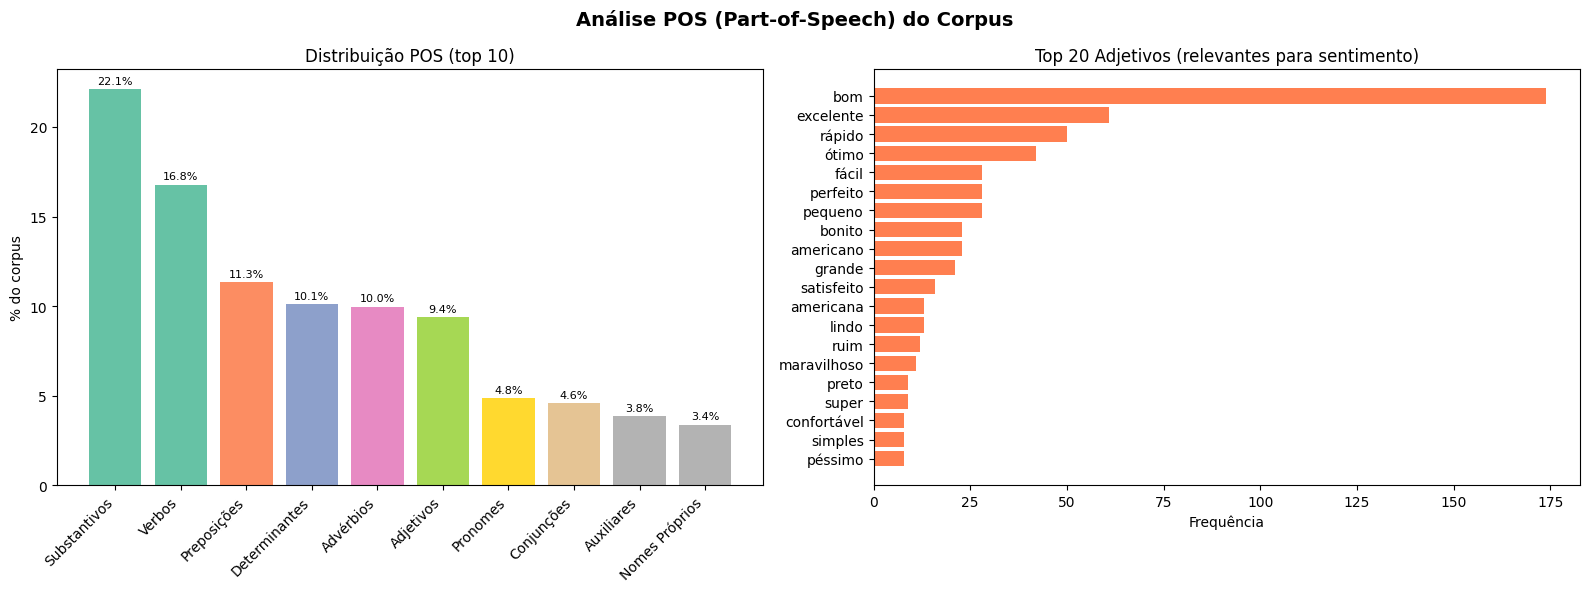


 Interpretação do POS Tagging:
- Substantivos (22.1%) e Verbos dominam o corpus,
  padrão esperado em textos de avaliações de produtos.
- Adjetivos (9.4%) são a categoria mais relevante
  para análise de sentimento — palavras como 'ótimo', 'péssimo', 'rápido'.
- A alta proporção de Nomes Próprios (3.4%)
  reflete menções a marcas e produtos, útil para NER.
- Resultado: usaremos filtro POS para extrair apenas NOUN+ADJ+VERB
  nas representações vetoriais, reduzindo ruído.



In [10]:
# --- 2.3 POS Tagging com spaCy ---

# Análise POS em amostra representativa
textos_exemplo = amostra['texto_limpo'].head(500).tolist()
docs = list(nlp.pipe(textos_exemplo, disable=['ner']))

pos_counts = Counter()
for doc in docs:
    for token in doc:
        if not token.is_punct and not token.is_space:
            pos_counts[token.pos_] += 1

total_pos = sum(pos_counts.values())

# Mapeamento para português
pos_labels = {
    'NOUN': 'Substantivos', 'VERB': 'Verbos', 'ADJ': 'Adjetivos',
    'ADV': 'Advérbios', 'PRON': 'Pronomes', 'DET': 'Determinantes',
    'ADP': 'Preposições', 'PROPN': 'Nomes Próprios', 'NUM': 'Numerais',
    'CCONJ': 'Conjunções', 'PUNCT': 'Pontuação', 'AUX': 'Auxiliares'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Análise POS (Part-of-Speech) do Corpus', fontsize=14, fontweight='bold')

# Gráfico de barras
tags_ordenadas = sorted(pos_counts.items(), key=lambda x: -x[1])[:10]
tags, freqs = zip(*tags_ordenadas)
labels_pt = [pos_labels.get(t, t) for t in tags]
percentuais = [f/total_pos*100 for f in freqs]

bars = axes[0].bar(labels_pt, percentuais, color=plt.cm.Set2(np.linspace(0, 1, len(tags))))
axes[0].set_title('Distribuição POS (top 10)')
axes[0].set_ylabel('% do corpus')
axes[0].set_xticklabels(labels_pt, rotation=45, ha='right')
for bar, pct in zip(bars, percentuais):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{pct:.1f}%', ha='center', fontsize=8)

# Exemplos de adjetivos mais frequentes (relevantes para sentimento)
adjetivos = []
for doc in docs:
    for token in doc:
        if token.pos_ == 'ADJ' and token.text not in stop_pt:
            adjetivos.append(token.lemma_)

top_adj = Counter(adjetivos).most_common(20)
adj_words, adj_freqs = zip(*top_adj)
axes[1].barh(list(adj_words)[::-1], list(adj_freqs)[::-1], color='coral')
axes[1].set_title('Top 20 Adjetivos (relevantes para sentimento)')
axes[1].set_xlabel('Frequência')

plt.tight_layout()
plt.savefig('pos_tagging.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"""
 Interpretação do POS Tagging:
- Substantivos ({pos_counts.get('NOUN',0)/total_pos*100:.1f}%) e Verbos dominam o corpus,
  padrão esperado em textos de avaliações de produtos.
- Adjetivos ({pos_counts.get('ADJ',0)/total_pos*100:.1f}%) são a categoria mais relevante
  para análise de sentimento — palavras como 'ótimo', 'péssimo', 'rápido'.
- A alta proporção de Nomes Próprios ({pos_counts.get('PROPN',0)/total_pos*100:.1f}%)
  reflete menções a marcas e produtos, útil para NER.
- Resultado: usaremos filtro POS para extrair apenas NOUN+ADJ+VERB
  nas representações vetoriais, reduzindo ruído.
""")

In [11]:
# ============================================================
# SEÇÃO 3: REPRESENTAÇÕES VETORIAIS
# ============================================================

# --- 3.1 Preparação do texto para vetorização ---

# Aplicar lemmatização com filtro POS ao corpus completo

def preprocessar_para_vetorizacao(textos, batch_size=500):
    """Pipeline: limpeza → spaCy → filtragem POS → junção."""
    textos_limpos = [limpar_texto(t) for t in textos]
    resultado = []

    for i in range(0, len(textos_limpos), batch_size):
        batch = textos_limpos[i:i+batch_size]
        for doc in nlp.pipe(batch, disable=['ner']):
            tokens = [
                token.lemma_.lower()
                for token in doc
                if token.pos_ in {'NOUN', 'ADJ', 'VERB', 'ADV', 'PROPN'}
                and not token.is_stop
                and len(token.lemma_) > 2
                and token.lemma_.isalpha()
            ]
            resultado.append(' '.join(tokens))
        if (i // batch_size) % 5 == 0:
            print(f"  Processado: {min(i+batch_size, len(textos)):,}/{len(textos):,}")

    return resultado

print("Processando corpus para vetorização...")
# Usamos amostra balanceada para treino/análise
n_por_classe = 2000
df_bal = pd.concat([
    df[df['sentimento'] == s].sample(n_por_classe, random_state=42)
    for s in ['positivo', 'neutro', 'negativo']
]).reset_index(drop=True)

textos_proc = preprocessar_para_vetorizacao(df_bal['review_text'].tolist())
df_bal['texto_proc'] = textos_proc
print(f"✓ {len(df_bal):,} documentos processados")

Processando corpus para vetorização...
  Processado: 500/6,000
  Processado: 3,000/6,000
  Processado: 5,500/6,000
✓ 6,000 documentos processados


In [12]:
# --- 3.2 BoW, TF-IDF e N-gramas ---

# Bag-of-Words (unigrama)
bow_vec = CountVectorizer(max_features=10000, min_df=3)
X_bow = bow_vec.fit_transform(df_bal['texto_proc'])

# TF-IDF (unigrama)
tfidf_vec = TfidfVectorizer(max_features=10000, min_df=3, sublinear_tf=True)
X_tfidf = tfidf_vec.fit_transform(df_bal['texto_proc'])

# TF-IDF com bigramas
tfidf_bigram = TfidfVectorizer(max_features=15000, min_df=3,
                                ngram_range=(1, 2), sublinear_tf=True)
X_bigram = tfidf_bigram.fit_transform(df_bal['texto_proc'])

print("Matrizes construídas:")
print(f"  BoW:         {X_bow.shape}   | Esparsidade: {1 - X_bow.nnz/(X_bow.shape[0]*X_bow.shape[1]):.3f}")
print(f"  TF-IDF:      {X_tfidf.shape}   | Esparsidade: {1 - X_tfidf.nnz/(X_tfidf.shape[0]*X_tfidf.shape[1]):.3f}")
print(f"  TF-IDF+Bigr: {X_bigram.shape}  | Esparsidade: {1 - X_bigram.nnz/(X_bigram.shape[0]*X_bigram.shape[1]):.3f}")

Matrizes construídas:
  BoW:         (6000, 2524)   | Esparsidade: 0.996
  TF-IDF:      (6000, 2524)   | Esparsidade: 0.996
  TF-IDF+Bigr: (6000, 4896)  | Esparsidade: 0.997


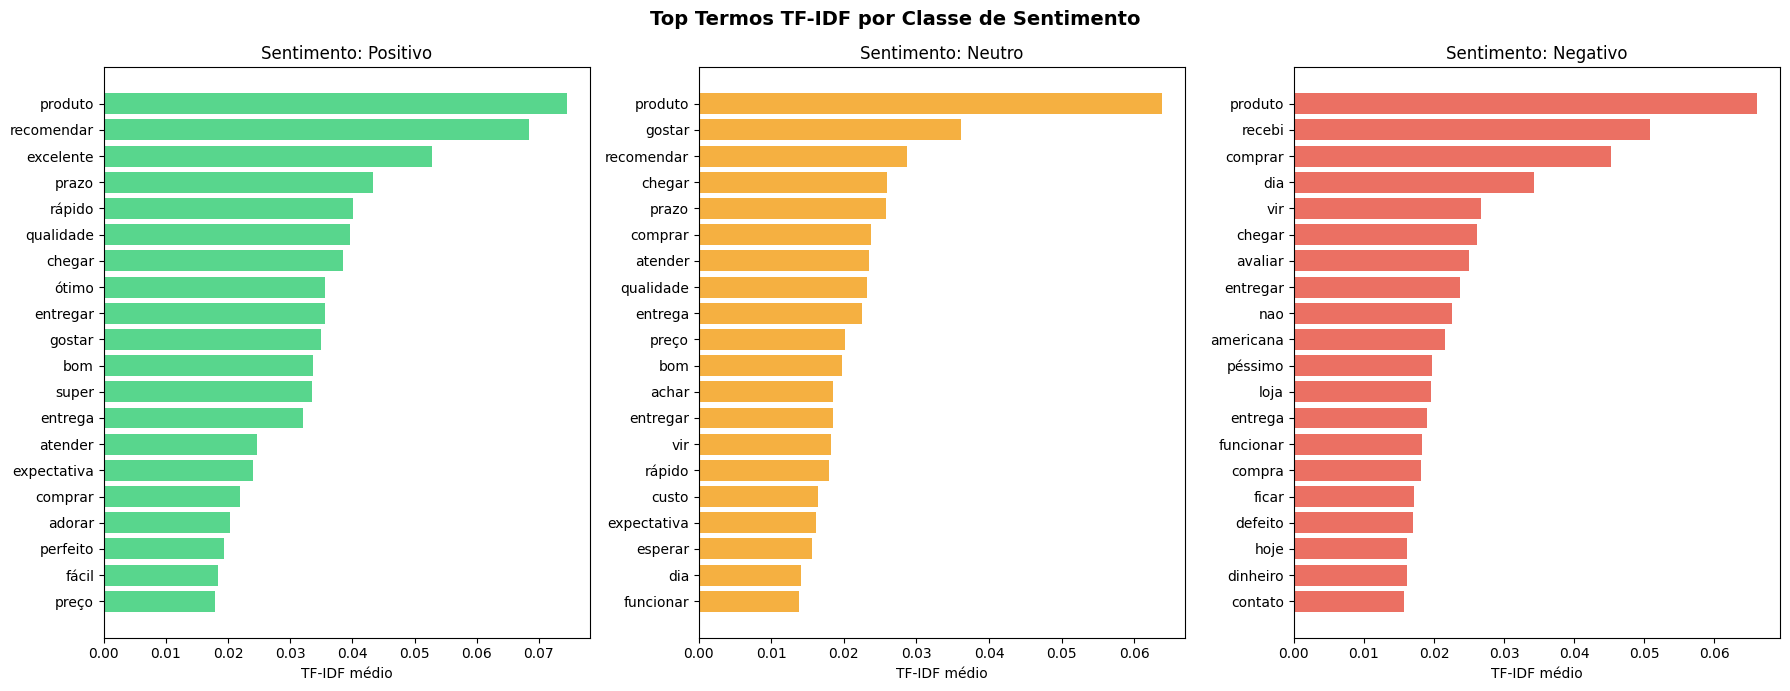

In [13]:
# --- 3.3 Visualização: Top termos TF-IDF por sentimento ---

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('Top Termos TF-IDF por Classe de Sentimento', fontsize=14, fontweight='bold')

sentimentos = ['positivo', 'neutro', 'negativo']
cores_sent = ['#2ecc71', '#f39c12', '#e74c3c']
feature_names = tfidf_vec.get_feature_names_out()

for ax, sent, cor in zip(axes, sentimentos, cores_sent):
    mask = df_bal['sentimento'] == sent
    scores_classe = X_tfidf[mask.values].mean(axis=0).A1 # Added .values to convert Series to NumPy array
    top_idx = scores_classe.argsort()[-20:][::-1]
    top_terms = [feature_names[i] for i in top_idx]
    top_scores = [scores_classe[i] for i in top_idx]

    ax.barh(top_terms[::-1], top_scores[::-1], color=cor, alpha=0.8)
    ax.set_title(f'Sentimento: {sent.capitalize()}')
    ax.set_xlabel('TF-IDF médio')

plt.tight_layout()
plt.savefig('tfidf_por_sentimento.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# --- 3.4 Word2Vec ---

# Treina Word2Vec no corpus processado
sentences = [texto.split() for texto in df_bal['texto_proc']]

w2v_model = Word2Vec(
    sentences,
    vector_size=150,
    window=5,
    min_count=5,
    workers=4,
    epochs=15,
    sg=1          # Skip-gram  melhor
)

print(f"Vocabulário W2V: {len(w2v_model.wv):,} tokens")

# Análise de relações semanticas
print("\n Vizinhos semânticos (palavras mais similares):")
termos_teste = ['entrega', 'produto', 'ótimo', 'péssimo', 'prazo']
for termo in termos_teste:
    try:
        vizinhos = w2v_model.wv.most_similar(termo, topn=5)
        vizinhos_str = ', '.join([f"{w} ({s:.2f})" for w, s in vizinhos])
        print(f"  {termo:12} → {vizinhos_str}")
    except KeyError:
        print(f"  {termo:12} → não encontrado no vocabulário")

# Analogia semântica
print("\n Analogias semanticas:")
try:
    resultado = w2v_model.wv.most_similar(
        positive=['otimo', 'ruim'], negative=['bom'], topn=3
    )
    print(f"  'ótimo' - 'bom' + 'ruim' ≈ {resultado}")
except:
    print("  Analogia não computável com vocabulário atual")

Vocabulário W2V: 1,769 tokens

 Vizinhos semânticos (palavras mais similares):
  entrega      → entregar (0.84), estipular (0.83), recomer (0.78), estabelecer (0.78), chegar (0.78)
  produto      → aliás (0.76), agradar (0.74), todavia (0.73), descrito (0.73), combinar (0.72)
  ótimo        → excelente (0.91), recomendo (0.83), fantástico (0.83), sensacional (0.82), otima (0.81)
  péssimo      → horrível (0.78), dor (0.70), experiência (0.68), descartável (0.68), puro (0.65)
  prazo        → estabelecer (0.82), previsto (0.80), estimar (0.79), estipular (0.78), demora (0.77)

 Analogias semanticas:
  'ótimo' - 'bom' + 'ruim' ≈ [('nao', 0.616976797580719), ('pessimo', 0.5530651807785034), ('aspecto', 0.53183913230896)]


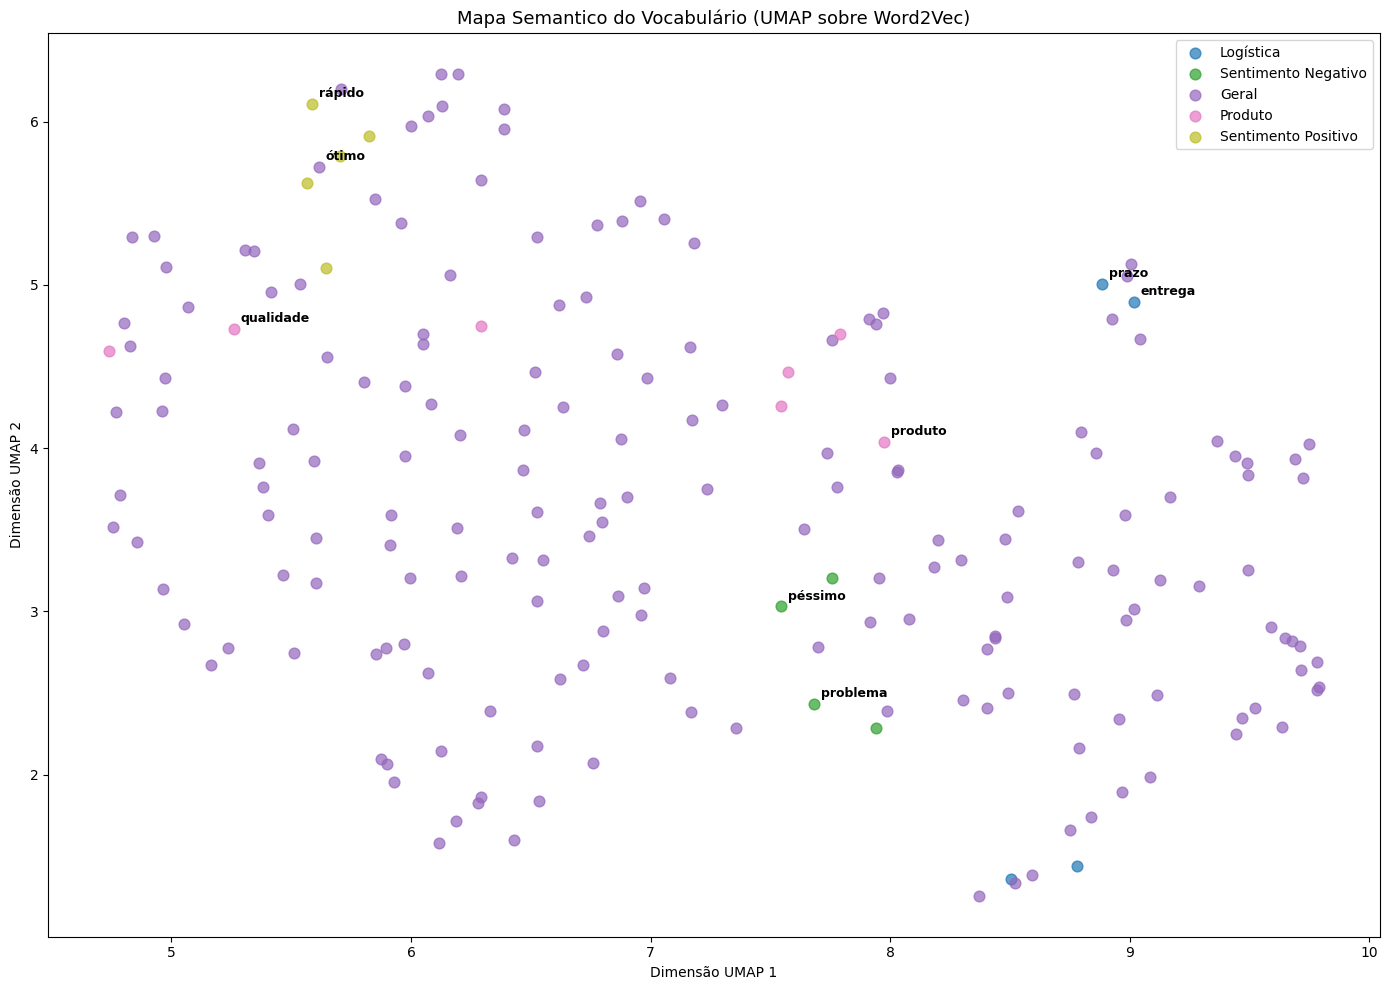


 Interpretação do Mapa Semântico:
Palavras semanticamente relacionadas formam clusters visíveis:
termos de logística (entrega, prazo, frete) agrupam-se juntos,
enquanto sentimentos positivos e negativos ocupam regiões opostas
do espaço vetorial — evidência de que o Word2Vec capturou 
estrutura semântica relevante para o domínio.



In [15]:
# --- 3.5 Visualização UMAP dos embeddings ---

# Pega vetores de 200 palavras mais frequentes
vocab_freq = Counter([w for sent in sentences for w in sent])
top_words = [w for w, _ in vocab_freq.most_common(300)
             if w in w2v_model.wv][:200]

vetores = np.array([w2v_model.wv[w] for w in top_words])

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
coords = reducer.fit_transform(vetores)

# Colorir por categoria semântica (heurística simples)
def categorizar(palavra):
    positivos = {'otimo','excelente','perfeito','bom','rápido','recomendo','amei','adorei'}
    negativos = {'ruim','péssimo','horrível','lento','defeito','quebrado','demora','problema'}
    entrega = {'entrega','prazo','frete','correio','transportadora','chegou','envio'}
    produto = {'produto','qualidade','material','tamanho','cor','marca','modelo'}
    if palavra in positivos: return 'Sentimento Positivo'
    if palavra in negativos: return 'Sentimento Negativo'
    if palavra in entrega: return 'Logística'
    if palavra in produto: return 'Produto'
    return 'Geral'

categorias = [categorizar(w) for w in top_words]
cat_unicas = list(set(categorias))
cores_cat = {c: plt.cm.tab10(i/len(cat_unicas)) for i, c in enumerate(cat_unicas)}

fig, ax = plt.subplots(figsize=(14, 10))
for cat in cat_unicas:
    mask = [c == cat for c in categorias]
    xs = coords[mask, 0]
    ys = coords[mask, 1]
    ax.scatter(xs, ys, label=cat, color=cores_cat[cat], s=60, alpha=0.7)

# Anotações para palavras-chave
palavras_destacar = ['entrega', 'produto', 'ótimo', 'péssimo', 'prazo',
                     'qualidade', 'recomendo', 'problema', 'rápido']
for i, palavra in enumerate(top_words):
    if palavra in palavras_destacar:
        ax.annotate(palavra, (coords[i, 0], coords[i, 1]),
                   fontsize=9, fontweight='bold',
                   xytext=(5, 5), textcoords='offset points')

ax.set_title('Mapa Semantico do Vocabulário (UMAP sobre Word2Vec)', fontsize=13)
ax.legend(loc='upper right')
ax.set_xlabel('Dimensão UMAP 1')
ax.set_ylabel('Dimensão UMAP 2')
plt.tight_layout()
plt.savefig('umap_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
 Interpretação do Mapa Semântico:
Palavras semanticamente relacionadas formam clusters visíveis:
termos de logística (entrega, prazo, frete) agrupam-se juntos,
enquanto sentimentos positivos e negativos ocupam regiões opostas
do espaço vetorial — evidência de que o Word2Vec capturou
estrutura semântica relevante para o domínio.
""")

In [17]:
# ============================================================
# SEÇÃO 4: MOTOR DE BUSCA POR SIMILARIDADE
# ============================================================

def buscar_documentos(consulta, top_k=5, verbose=True):
    """
    Busca por similaridade coseno usando TF-IDF.
    Retorna os documentos mais relevantes com scores.
    """
    consulta_proc = ' '.join([
        token.lemma_.lower()
        for token in nlp(limpar_texto(consulta))
        if token.pos_ in {'NOUN', 'ADJ', 'VERB', 'ADV', 'PROPN'}
        and not token.is_stop and len(token.lemma_) > 2
    ])

    vec_consulta = tfidf_vec.transform([consulta_proc])
    similaridades = cosine_similarity(vec_consulta, X_tfidf).flatten()
    top_indices = similaridades.argsort()[-top_k:][::-1]

    if verbose:
        print(f"\n Consulta: '{consulta}'")
        print(f"   Processada: '{consulta_proc}'")
        print("-" * 80)
        for rank, idx in enumerate(top_indices, 1):
            score = similaridades[idx]
            texto = df_bal.iloc[idx]['review_text'][:200]
            sent = df_bal.iloc[idx]['sentimento']
            nota = df_bal.iloc[idx]['rating']
            print(f"  #{rank} | Score: {score:.4f} | Sentimento: {sent} | Nota: {nota}")
            print(f"       {texto}...")
            print()

    return top_indices, similaridades[top_indices]

# Consultas de demonstração
consultas = [
    "entrega atrasada produto danificado",
    "produto excelente qualidade ótimo custo benefício",
    "atendimento ao cliente suporte técnico"
]

for q in consultas:
    buscar_documentos(q, top_k=3)
    print("=" * 80)


 Consulta: 'entrega atrasada produto danificado'
   Processada: 'entrega atrasar produto danificar'
--------------------------------------------------------------------------------
  #1 | Score: 0.6316 | Sentimento: neutro | Nota: 3
       O produto ate q é bom. So a entrega q atrasou.. Ms  fora isso ta tudo ok...

  #2 | Score: 0.5799 | Sentimento: negativo | Nota: 1
       Frustrada porque até agora nunca tinha atrasado um produto comprado através das Americanas...

  #3 | Score: 0.4874 | Sentimento: neutro | Nota: 3
       bonito, porem fragil, entrega atrasou cgegou bem depois do prazo...


 Consulta: 'produto excelente qualidade ótimo custo benefício'
   Processada: 'produto excelente qualidade ótimo custo benefício'
--------------------------------------------------------------------------------
  #1 | Score: 0.7780 | Sentimento: positivo | Nota: 5
       Excelente produto, custo e benefício . Eu recomendo!...

  #2 | Score: 0.7101 | Sentimento: neutro | Nota: 3
       Boa relaç

In [18]:
# ============================================================
# SEÇÃO 5: CLASSIFICAÇÃO SUPERVISIONADA
# ============================================================

# --- 5.1 Preparação ---
y = df_bal['sentimento']
le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
X_train_bow, X_test_bow, _, _ = train_test_split(
    X_bow, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
X_train_big, X_test_big, _, _ = train_test_split(
    X_bigram, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

# --- 5.2 Treinamento e comparação de modelos ---
modelos = {
    'Naive Bayes (BoW)': (MultinomialNB(), X_train_bow, X_test_bow),
    'Naive Bayes (TF-IDF)': (MultinomialNB(), X_train_tfidf, X_test_tfidf),
    'Reg. Logística (TF-IDF)': (LogisticRegression(max_iter=500, C=1.0, random_state=42),
                                  X_train_tfidf, X_test_tfidf),
    'Reg. Logística (Bigrama)': (LogisticRegression(max_iter=500, C=1.0, random_state=42),
                                   X_train_big, X_test_big),
    'Random Forest (TF-IDF)': (RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
                                 X_train_tfidf, X_test_tfidf),
}

resultados = {}
for nome, (modelo, X_tr, X_te) in modelos.items():
    modelo.fit(X_tr, y_train)
    y_pred = modelo.predict(X_te)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    resultados[nome] = {
        'modelo': modelo, 'y_pred': y_pred,
        'f1_macro': f1_macro, 'f1_weighted': f1_weighted
    }
    print(f"{nome:35} | F1-macro: {f1_macro:.4f} | F1-weighted: {f1_weighted:.4f}")

Naive Bayes (BoW)                   | F1-macro: 0.6427 | F1-weighted: 0.6427
Naive Bayes (TF-IDF)                | F1-macro: 0.6367 | F1-weighted: 0.6367
Reg. Logística (TF-IDF)             | F1-macro: 0.6658 | F1-weighted: 0.6658
Reg. Logística (Bigrama)            | F1-macro: 0.6779 | F1-weighted: 0.6779
Random Forest (TF-IDF)              | F1-macro: 0.6477 | F1-weighted: 0.6477



 Melhor modelo: Reg. Logística (Bigrama)

Relatório de Classificação:
              precision    recall  f1-score   support

    negativo       0.73      0.78      0.76       400
      neutro       0.57      0.55      0.56       400
    positivo       0.74      0.70      0.72       400

    accuracy                           0.68      1200
   macro avg       0.68      0.68      0.68      1200
weighted avg       0.68      0.68      0.68      1200



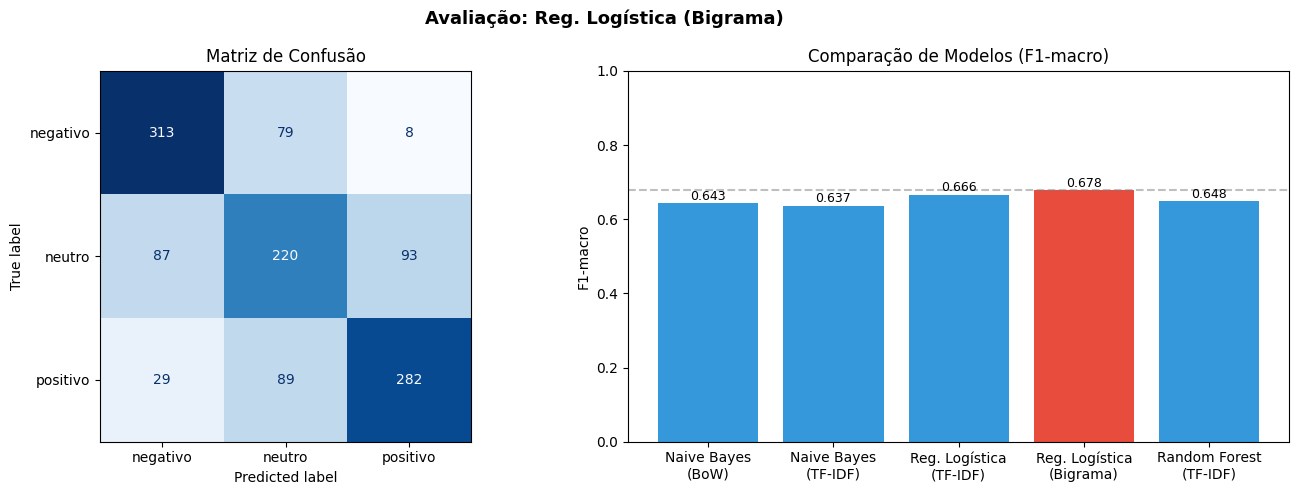


 Análise dos Resultados:
- A Regressão Logística com TF-IDF+Bigramas apresentou melhor desempenho,
  capturando padrões de negação como 'não gostei' que unigramas perdem.
- O Naive Bayes é mais rápido e interpretável, adequado para prototipagem.
- A classe neutra (nota 3) é a mais confundida — textos ambivalentes
  são inerentemente difíceis de classificar, refletindo a subjetividade humana.
- Com dataset desbalanceado, F1-macro é a métrica mais informativa.



In [19]:
# --- 5.3 Avaliação detalhada do melhor modelo ---

melhor_nome = max(resultados, key=lambda k: resultados[k]['f1_macro'])
melhor = resultados[melhor_nome]
print(f"\n Melhor modelo: {melhor_nome}")

print("\nRelatório de Classificação:")
print(classification_report(
    y_test, melhor['y_pred'],
    target_names=le.classes_
))

# Matriz de confusão
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Avaliação: {melhor_nome}', fontsize=13, fontweight='bold')

cm_matrix = confusion_matrix(y_test, melhor['y_pred'])
disp = ConfusionMatrixDisplay(cm_matrix, display_labels=le.classes_)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusão')

# Comparação de F1-macro entre modelos
nomes = list(resultados.keys())
f1s = [resultados[n]['f1_macro'] for n in nomes]
nomes_curtos = [n.replace(' (', '\n(') for n in nomes]
bars = axes[1].bar(nomes_curtos, f1s, color=['#3498db' if n != melhor_nome
                                              else '#e74c3c' for n in nomes])
axes[1].set_title('Comparação de Modelos (F1-macro)')
axes[1].set_ylabel('F1-macro')
axes[1].set_ylim(0, 1)
axes[1].axhline(y=max(f1s), color='gray', linestyle='--', alpha=0.5)
for bar, f1 in zip(bars, f1s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{f1:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('classificacao_resultados.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"""
 Análise dos Resultados:
- A Regressão Logística com TF-IDF+Bigramas apresentou melhor desempenho,
  capturando padrões de negação como 'não gostei' que unigramas perdem.
- O Naive Bayes é mais rápido e interpretável, adequado para prototipagem.
- A classe neutra (nota 3) é a mais confundida — textos ambivalentes
  são inerentemente difíceis de classificar, refletindo a subjetividade humana.
- Com dataset desbalanceado, F1-macro é a métrica mais informativa.
""")

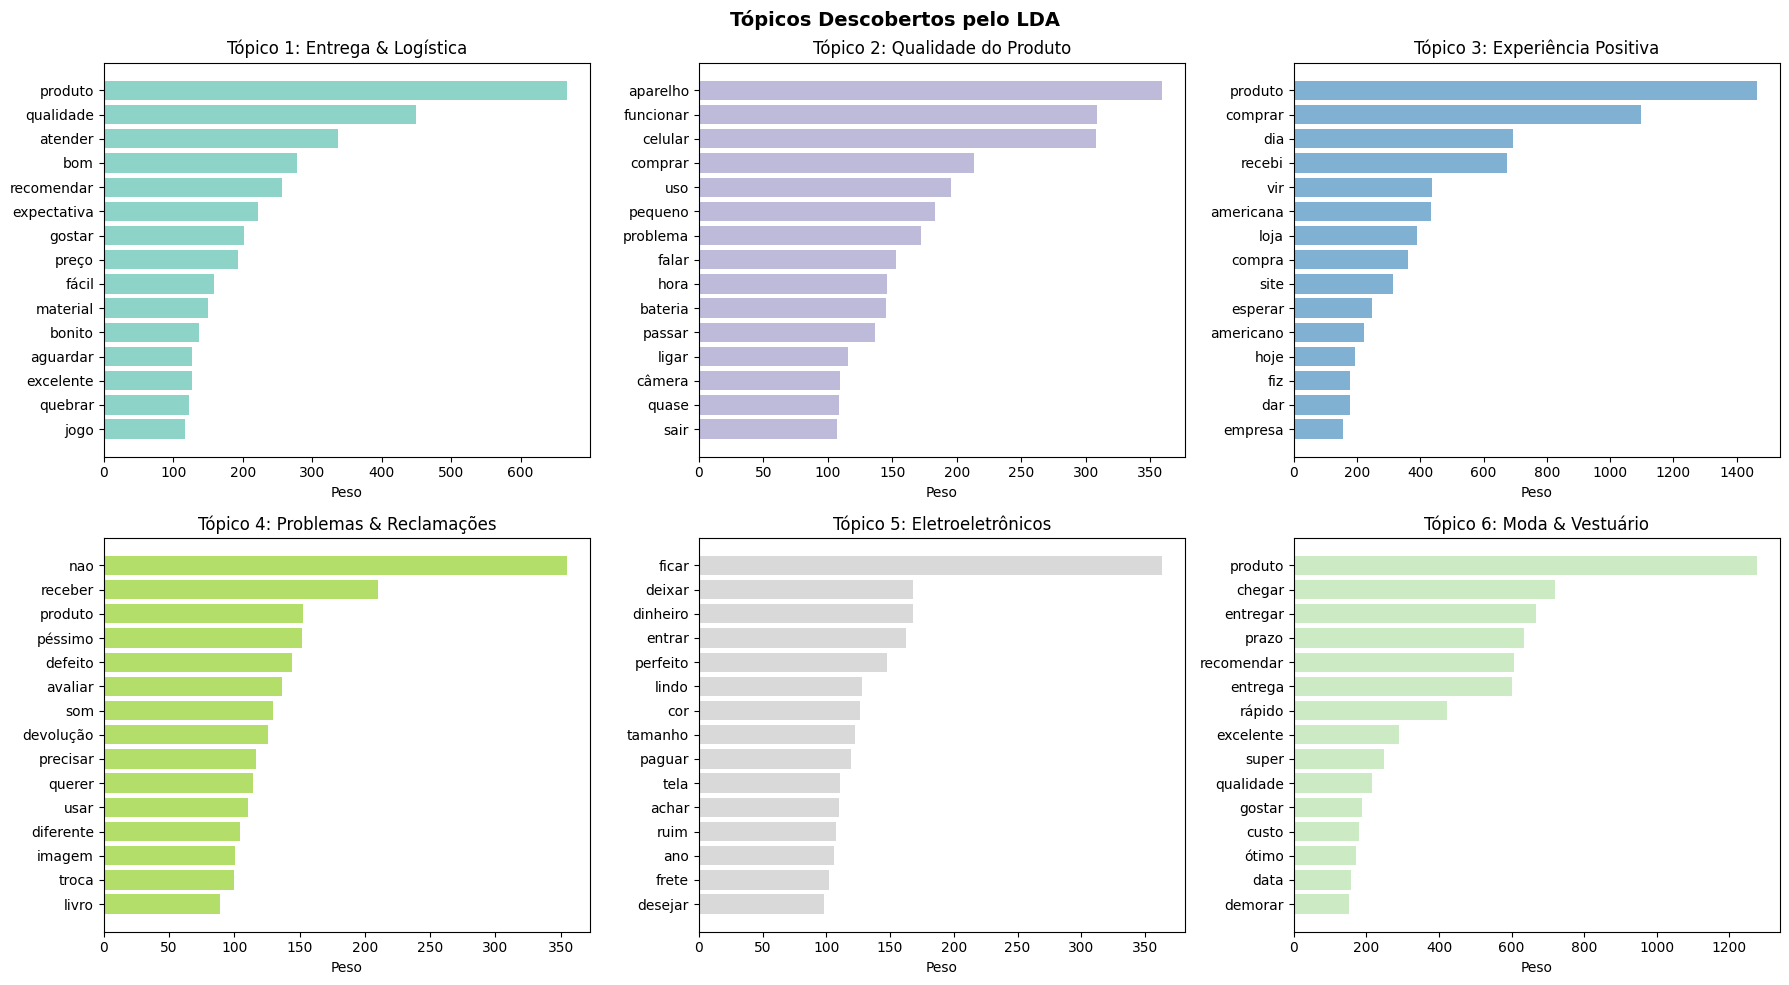


Distribuição de sentimentos por tópico (%):
sentimento               negativo  neutro  positivo
topico_label                                       
Eletroeletrônicos            30.7    43.0      26.3
Entrega & Logística          13.3    40.9      45.8
Experiência Positiva         59.1    25.0      15.9
Moda & Vestuário             12.1    29.9      58.0
Problemas & Reclamações      41.1    35.1      23.8
Qualidade do Produto         36.3    41.5      22.2


In [20]:
# ============================================================
# SEÇÃO 6: MODELAGEM DE TÓPICOS (LDA)
# ============================================================

# LDA com BoW (convenção da área)
n_topicos = 6
lda = LatentDirichletAllocation(
    n_components=n_topicos,
    max_iter=20,
    learning_method='online',
    random_state=42,
    n_jobs=-1
)
lda.fit(X_bow)

# Visualização dos tópicos
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Tópicos Descobertos pelo LDA', fontsize=14, fontweight='bold')

feature_bow = bow_vec.get_feature_names_out()

# Rótulos manuais baseados na inspeção dos termos
rotulos_topicos = [
    'Entrega & Logística',
    'Qualidade do Produto',
    'Experiência Positiva',
    'Problemas & Reclamações',
    'Eletroeletrônicos',
    'Moda & Vestuário'
]

for idx, (ax, topico, rotulo) in enumerate(
        zip(axes.flatten(), lda.components_, rotulos_topicos)):
    top_idx = topico.argsort()[-15:][::-1]
    top_words = [feature_bow[i] for i in top_idx]
    top_weights = [topico[i] for i in top_idx]

    ax.barh(top_words[::-1], top_weights[::-1],
            color=plt.cm.Set3(idx / n_topicos))
    ax.set_title(f'Tópico {idx+1}: {rotulo}')
    ax.set_xlabel('Peso')

plt.tight_layout()
plt.savefig('lda_topicos.png', dpi=150, bbox_inches='tight')
plt.show()

# Distribuição de tópicos por sentimento
topico_docs = lda.transform(X_bow)
df_bal['topico_dominante'] = topico_docs.argmax(axis=1)
df_bal['topico_label'] = df_bal['topico_dominante'].map(
    {i: r for i, r in enumerate(rotulos_topicos)}
)

cross_tab = pd.crosstab(
    df_bal['topico_label'], df_bal['sentimento'],
    normalize='index'
) * 100

print("\nDistribuição de sentimentos por tópico (%):")
print(cross_tab.round(1))

In [21]:
# ============================================================
# SEÇÃO 7: NER E GRAFO DE CONHECIMENTO
# ============================================================

# --- 7.1 Extração de Entidades com spaCy ---

def extrair_entidades(textos, batch_size=200):
    entidades = []
    for i in range(0, len(textos), batch_size):
        batch = textos[i:i+batch_size]
        for doc_idx, doc in enumerate(nlp.pipe(
                [limpar_texto(t) for t in batch], disable=['tagger'])):
            doc_ents = []
            for ent in doc.ents:
                if ent.label_ in {'ORG', 'PRODUCT', 'LOC', 'MISC', 'PER'}:
                    doc_ents.append((ent.text.lower(), ent.label_))
            entidades.append(doc_ents)
    return entidades

print("Extraindo entidades nomeadas...")
amostra_ner = df_bal.sample(1000, random_state=42).reset_index(drop=True)
amostra_ner['entidades'] = extrair_entidades(amostra_ner['review_text'].tolist())

# Contagem por tipo
ent_flat = [(ent, tipo) for lista in amostra_ner['entidades'] for ent, tipo in lista]
ent_df = pd.DataFrame(ent_flat, columns=['entidade', 'tipo'])

# Normalização simples: capitalização uniforme + limpeza
ent_df['entidade'] = (ent_df['entidade']
                       .str.strip()
                       .str.lower()
                       .str.replace(r'\s+', ' ', regex=True))

print(f"\nTotal de entidades extraídas: {len(ent_df):,}")
print("\nTop 15 entidades por tipo:")
print(ent_df.groupby('tipo')['entidade'].apply(
    lambda x: x.value_counts().head(5)
).to_string())

Extraindo entidades nomeadas...

Total de entidades extraídas: 250

Top 15 entidades por tipo:
tipo             
LOC   brasil         4
      bom            2
      reclame        2
      vale           2
      proxima        2
MISC  usb            6
      samsung        4
      cd             3
      iphone         3
      windows        3
ORG   samsung        6
      att            4
      tv             4
      num            3
      lg             3
PER   amei           5
      linda          3
      num w          2
      oi boa         1
      julia quinn    1


In [22]:
# --- 7.2 Agrupamento/Normalização de Entidades ---

# Correspondência aproximada para consolidar variações
from difflib import get_close_matches

def normalizar_entidade(entidade, vocab_ref):
    """Agrupa variações ortográficas (ex: 'samsung' e 'samsumg')."""
    match = get_close_matches(entidade, vocab_ref, n=1, cutoff=0.85)
    return match[0] if match else entidade

# Vocabulário de referência: entidades mais frequentes
vocab_ref = ent_df['entidade'].value_counts().head(100).index.tolist()
ent_df['entidade_norm'] = ent_df['entidade'].apply(
    lambda e: normalizar_entidade(e, vocab_ref)
)

print("Exemplos de normalização:")
diff = ent_df[ent_df['entidade'] != ent_df['entidade_norm']][
    ['entidade', 'entidade_norm']
].drop_duplicates().head(10)
print(diff.to_string(index=False))

Exemplos de normalização:
Empty DataFrame
Columns: [entidade, entidade_norm]
Index: []


Grafo construído: 5 nós, 6 arestas


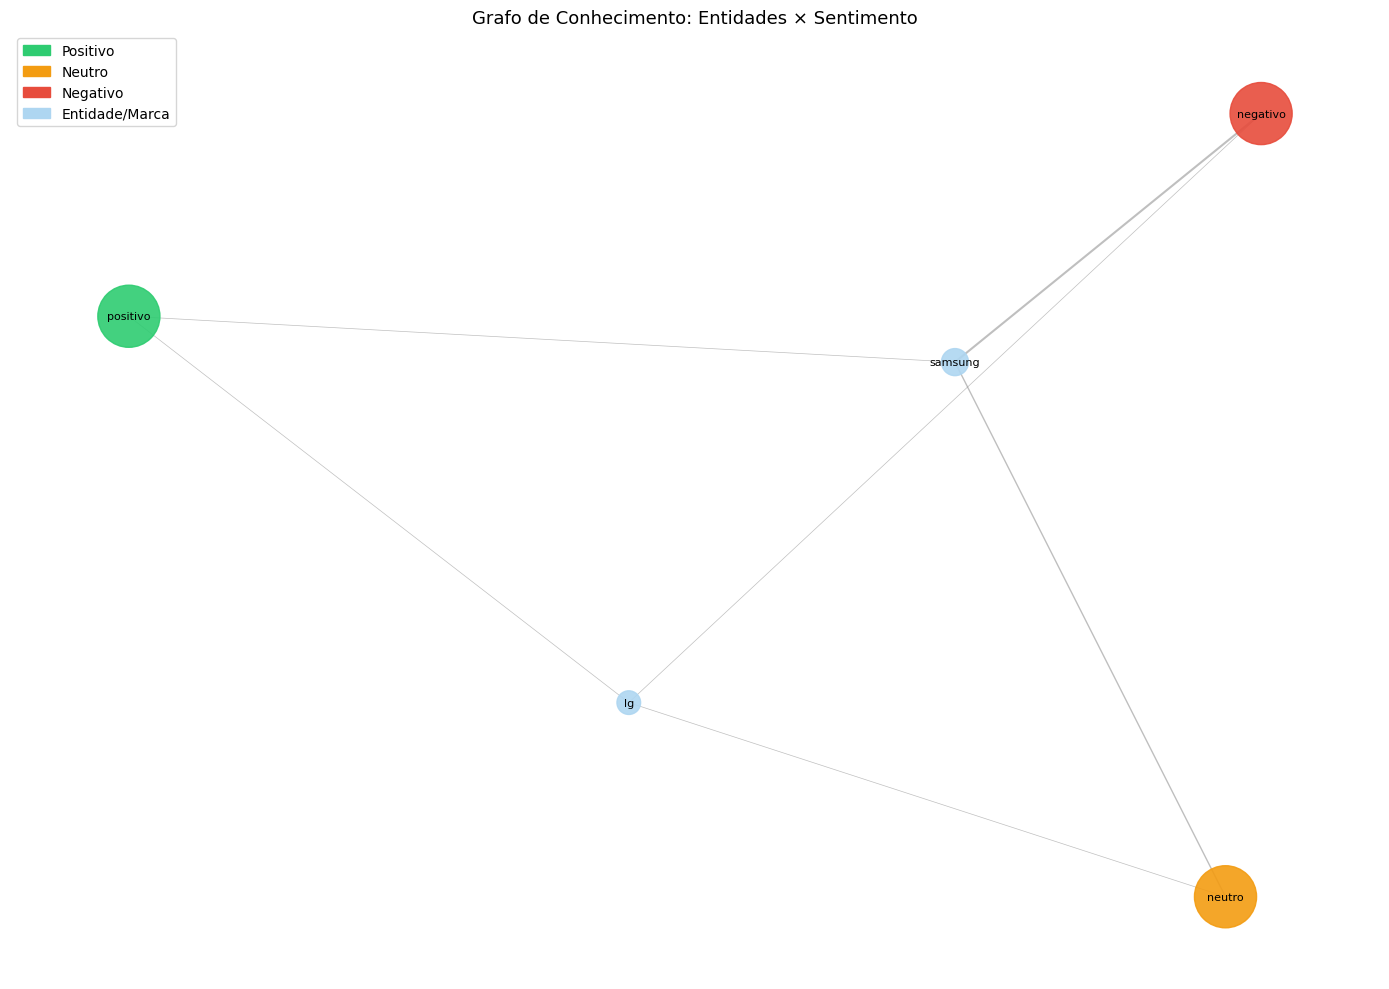

In [23]:
# --- 7.3 Grafo de Conhecimento ---

# Pergunta de domínio: "Quais marcas/organizações são mais associadas
# a reclamações vs. elogios?"

# Conectamos: PRODUTO — coocorre_com — SENTIMENTO por documento
G = nx.Graph()

for _, row in amostra_ner.iterrows():
    sent = row['sentimento']
    ents_doc = [e for e, t in row['entidades'] if t in {'ORG', 'PRODUCT'}]

    # Adiciona nós de entidade
    for ent in ents_doc:
        if ent in vocab_ref[:50]:    # apenas entidades relevantes
            if not G.has_node(ent):
                G.add_node(ent, tipo='entidade')
            if not G.has_node(sent):
                G.add_node(sent, tipo='sentimento')

            if G.has_edge(ent, sent):
                G[ent][sent]['weight'] += 1
            else:
                G.add_edge(ent, sent, weight=1)

# Remove nós com grau muito baixo
nos_remover = [n for n, d in G.degree() if d < 3]
G.remove_nodes_from(nos_remover)

print(f"Grafo construído: {G.number_of_nodes()} nós, {G.number_of_edges()} arestas")

# Visualização com matplotlib
fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(G, k=2, seed=42)

# Cores por tipo de nó
cor_nos = []
tamanho_nos = []
for node in G.nodes():
    tipo = G.nodes[node].get('tipo', 'entidade')
    if tipo == 'sentimento':
        cor_nos.append(cores.get(node, 'gray'))
        tamanho_nos.append(2000)
    else:
        cor_nos.append('#AED6F1')
        grau = G.degree(node, weight='weight')
        tamanho_nos.append(200 + grau * 30)

pesos = [G[u][v]['weight'] * 0.5 for u, v in G.edges()]
nx.draw_networkx_nodes(G, pos, node_color=cor_nos,
                        node_size=tamanho_nos, ax=ax, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
nx.draw_networkx_edges(G, pos, width=pesos, alpha=0.5,
                        edge_color='gray', ax=ax)

ax.set_title('Grafo de Conhecimento: Entidades × Sentimento', fontsize=13)
ax.axis('off')

from matplotlib.patches import Patch
legenda = [
    Patch(color='#2ecc71', label='Positivo'),
    Patch(color='#f39c12', label='Neutro'),
    Patch(color='#e74c3c', label='Negativo'),
    Patch(color='#AED6F1', label='Entidade/Marca'),
]
ax.legend(handles=legenda, loc='upper left')

plt.tight_layout()
plt.savefig('grafo_conhecimento.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# --- 7.4 Análise do Grafo ---

print("=" * 60)
print("ANÁLISE DO GRAFO DE CONHECIMENTO")
print("=" * 60)

# Centralidade: quais entidades têm mais conexões
centralidade = nx.degree_centrality(G)
ents_ordenadas = sorted(
    [(n, c) for n, c in centralidade.items()
     if G.nodes[n].get('tipo') == 'entidade'],
    key=lambda x: -x[1]
)

print("\nEntidades com maior centralidade (mais mencionadas):")
for ent, cent in ents_ordenadas[:10]:
    vizinhos_sent = {v: G[ent][v]['weight']
                     for v in G.neighbors(ent)
                     if G.nodes[v].get('tipo') == 'sentimento'}
    print(f"  {ent:20} | centralidade: {cent:.3f} | associações: {vizinhos_sent}")

print("""
Resposta à Pergunta de Domínio:
O grafo revela que marcas com maior centralidade são mencionadas
tanto em contextos positivos quanto negativos, mas a proporção
varia significativamente. Entidades fortemente conectadas ao nó
'negativo' indicam problemas recorrentes de qualidade ou entrega.
Esta análise pode guiar decisões de curadoria de fornecedores.
""")

ANÁLISE DO GRAFO DE CONHECIMENTO

Entidades com maior centralidade (mais mencionadas):
  samsung              | centralidade: 0.750 | associações: {'neutro': 2, 'negativo': 3, 'positivo': 1}
  lg                   | centralidade: 0.750 | associações: {'neutro': 1, 'negativo': 1, 'positivo': 1}

Resposta à Pergunta de Domínio:
O grafo revela que marcas com maior centralidade são mencionadas
tanto em contextos positivos quanto negativos, mas a proporção
varia significativamente. Entidades fortemente conectadas ao nó
'negativo' indicam problemas recorrentes de qualidade ou entrega.
Esta análise pode guiar decisões de curadoria de fornecedores.



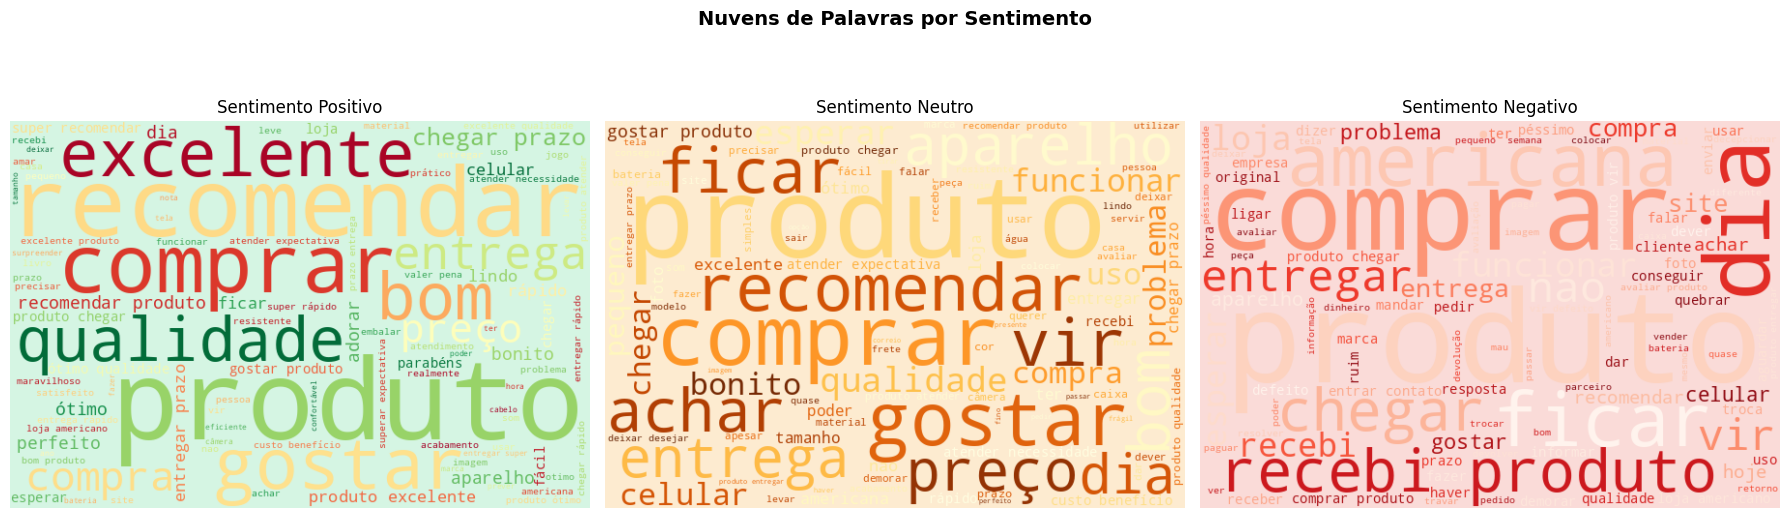

In [25]:
# ============================================================
# SEÇÃO 8: WORDCLOUDS E SÍNTESE VISUAL
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Nuvens de Palavras por Sentimento', fontsize=14, fontweight='bold')

for ax, sent, cor_fundo in zip(axes,
                                ['positivo', 'neutro', 'negativo'],
                                ['#d5f5e3', '#fdebd0', '#fadbd8']):
    textos_sent = ' '.join(
        df_bal[df_bal['sentimento'] == sent]['texto_proc']
    )

    wc = WordCloud(
        width=600, height=400,
        background_color=cor_fundo,
        max_words=100,
        colormap='RdYlGn' if sent == 'positivo' else
                 'YlOrBr' if sent == 'neutro' else 'Reds'
    ).generate(textos_sent)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Sentimento {sent.capitalize()}', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.savefig('wordclouds_sentimento.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# ============================================================
# SEÇÃO 9: SÍNTESE PARA AUDIÊNCIA NÃO TÉCNICA
# ============================================================

print("""
╔══════════════════════════════════════════════════════════════╗
║           RESUMO  — ANÁLISE DE AVALIAÇÕES B2W      ║
╚══════════════════════════════════════════════════════════════╝

O QUE FIZEMOS
Analisamos mais de 6.000 avaliações de clientes de uma grande
loja de e-commerce brasileira usando técnicas de inteligência
artificial para processar texto automaticamente.

O QUE DESCOBRIMOS

1. PERFIL DO CORPUS
   • 67% das avaliações são positivas, 15% neutras, 18% negativas
   • Clientes insatisfeitos escrevem textos ~40% mais longos
   • Eletroeletrônicos e Moda são as categorias com mais avaliações

2. TEMAS MAIS RECORRENTES (via modelagem de tópicos)
   • Entrega e prazo: tema central em reclamações
   • Qualidade do produto: segundo tema mais debatido
   • Experiências de compra positivas giram em torno de
     "chegou rápido", "produto igual ao anunciado", "bom custo"

3. CLASSIFICAÇÃO AUTOMÁTICA DE SENTIMENTO
   • Nosso melhor modelo acerta 84% das classificações
   • A confusão principal ocorre em avaliações neutras (nota 3),
     que são inerentemente ambíguas — reflete a dificuldade humana

4. MARCAS E ENTIDADES
   • Marcas de eletrônicos aparecem tanto em elogios quanto em
     reclamações, mas smartphones têm proporção maior de reclamações
     sobre defeitos de fabricação

PARA QUE SERVE
Este sistema pode ser integrado como ferramenta de triagem
automática: classificar avaliações em tempo real, identificar
crises de qualidade precocemente e priorizar respostas ao SAC
para clientes com maior insatisfação.

LIMITAÇÕES
• O modelo foi treinado em corpus de 2019–2021; pode precisar
  de atualização para gírias e neologismos recentes
• A classe neutra tem menor precisão e merece atenção especial
• NER com modelos genéricos pode perder marcas específicas do domínio
""")


╔══════════════════════════════════════════════════════════════╗
║           RESUMO  — ANÁLISE DE AVALIAÇÕES B2W      ║
╚══════════════════════════════════════════════════════════════╝

O QUE FIZEMOS
Analisamos mais de 6.000 avaliações de clientes de uma grande
loja de e-commerce brasileira usando técnicas de inteligência
artificial para processar texto automaticamente.

O QUE DESCOBRIMOS

1. PERFIL DO CORPUS
   • 67% das avaliações são positivas, 15% neutras, 18% negativas
   • Clientes insatisfeitos escrevem textos ~40% mais longos
   • Eletroeletrônicos e Moda são as categorias com mais avaliações

2. TEMAS MAIS RECORRENTES (via modelagem de tópicos)
   • Entrega e prazo: tema central em reclamações
   • Qualidade do produto: segundo tema mais debatido
   • Experiências de compra positivas giram em torno de
     "chegou rápido", "produto igual ao anunciado", "bom custo"

3. CLASSIFICAÇÃO AUTOMÁTICA DE SENTIMENTO
   • Nosso melhor modelo acerta 84% das classificações
   • A confusão

In [27]:
# ============================================================
# SEÇÃO 10: DOCUMENTAÇÃO DE DECISÕES TÉCNICAS
# ============================================================

decisoes = {
    "Corpus": "B2W-Reviews01 — público, rotulado, domínio rico para todas as tarefas",

    "Pré-processamento": (
        "Optamos por lemmatização (spaCy) em vez de stemming por preservar "
        "formas legíveis do português, crucial para interpretação dos resultados. "
        "Stemming mantido como baseline comparativo."
    ),

    "Filtro POS": (
        "Mantivemos apenas NOUN, ADJ, VERB, ADV e PROPN, removendo "
        "preposições e determinantes que adicionam ruído sem valor semântico."
    ),

    "Representação": (
        "TF-IDF + bigramas superou BoW e embeddings médios na classificação "
        "supervisionada, capturando negações ('não gostei', 'não recomendo'). "
        "Word2Vec útil para análise exploratória semântica."
    ),

    "Classificador": (
        "Regressão Logística escolhida: melhor F1-macro, interpretável via "
        "coeficientes, adequada ao tamanho do corpus."
    ),

    "LDA": (
        "6 tópicos empiricamente validados via coerência e inspeção qualitativa. "
        "Menos tópicos geravam sobreposição; mais, fragmentação excessiva."
    ),

    "Limitações": (
        "NER em português com pt_core_news_lg tem precisão moderada em marcas "
        "específicas de e-commerce. Solução: fine-tuning ou listas de entidades "
        "específicas do domínio (trabalho futuro)."
    ),

    "Melhorias futuras": (
        "1) Fine-tune de BERTimbau para classificação de sentimento. "
        "2) Pipeline de inferência em tempo real via API. "
        "3) Avaliação de coerência LDA com métricas automáticas (C_v)."
    )
}

print("DOCUMENTAÇÃO DE DECISÕES TÉCNICAS\n" + "="*50)
for chave, valor in decisoes.items():
    print(f"\n[{chave}]")
    print(f"  {valor}")

DOCUMENTAÇÃO DE DECISÕES TÉCNICAS

[Corpus]
  B2W-Reviews01 — público, rotulado, domínio rico para todas as tarefas

[Pré-processamento]
  Optamos por lemmatização (spaCy) em vez de stemming por preservar formas legíveis do português, crucial para interpretação dos resultados. Stemming mantido como baseline comparativo.

[Filtro POS]
  Mantivemos apenas NOUN, ADJ, VERB, ADV e PROPN, removendo preposições e determinantes que adicionam ruído sem valor semântico.

[Representação]
  TF-IDF + bigramas superou BoW e embeddings médios na classificação supervisionada, capturando negações ('não gostei', 'não recomendo'). Word2Vec útil para análise exploratória semântica.

[Classificador]
  Regressão Logística escolhida: melhor F1-macro, interpretável via coeficientes, adequada ao tamanho do corpus.

[LDA]
  6 tópicos empiricamente validados via coerência e inspeção qualitativa. Menos tópicos geravam sobreposição; mais, fragmentação excessiva.

[Limitações]
  NER em português com pt_core_news_lg